# Flood → Solar · M3 damage — capex-weighted depth-damage

**Peril:** Flood (riverine) · **Asset:** Solar · **Layer:** M3 (damage) · sub-peril `riverine`

**Goal:** map the M2 coupled flood depth → a **capex-weighted subsystem damage ratio**, then
`conditional_loss = exposure × Asset_DR(conditional_depth) × TIV`. The **house recipe** (same as hail / wildfire /
wind): per-subsystem logistic `DR(x)=L/(1+exp(-k(x-x0)))`, anchored `DR(0)=0`, blended by NREL capex weights.

**Curves = the canonical `infrasure-damage-curves` library — RIVERINE_FLOOD × solar** (`FLOOD_x_SOLAR.md`,
`master_curve_index.json`, priority 4). Intensity = **flood depth (ft) above ground**. The genuinely flood-specific
physics — the **height inversion** — is baked into each `x0`: ground-level **inverters drown at ~0.75 ft**, while
elevated **panels (x0 2.5 ft) survive shallow water**; underground **cables are resilient** (L 0.55). So no separate
mount-height step is needed — `x0` *is* the elevation. (Same library hail/wildfire/wind use; A22's "no curve" is
superseded.)

> Plan: [`m3_damage.md`](../../../../docs/plans/flood/m3_damage.md) · Curves vendored to
> `data/flood/damage_curves/` for reproducibility. **Confidence: medium**; duration unmodeled (Gen-1).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
OUT = ROOT / "data" / "flood"
FT_M = 0.3048

m2 = pd.DataFrame(json.loads((OUT / "flood_m2_coupling_manifest.json").read_text())["rows"])
print("M2 coupling contract (input — all sub-perils):")
print(m2[["sub_peril", "name", "rp_years", "exposure_fraction", "conditional_depth_m"]].to_string(index=False))

M2 coupling contract (input — all sub-perils):
sub_peril                  name  rp_years  exposure_fraction  conditional_depth_m
 riverine  Hayhurst Texas Solar       100              0.107                0.081
 riverine  Hayhurst Texas Solar       500              0.161                0.176
 riverine Elizabeth Solar Plant        10              0.088                0.298
 riverine Elizabeth Solar Plant        25              0.117                0.365
 riverine Elizabeth Solar Plant        50              0.140                0.414
 riverine Elizabeth Solar Plant       100              0.162                0.464
 riverine Elizabeth Solar Plant       500              0.191                0.604
  pluvial  Hayhurst Texas Solar        10              0.400                0.058
  pluvial  Hayhurst Texas Solar        25              0.400                0.084
  pluvial  Hayhurst Texas Solar        50              0.400                0.107
  pluvial  Hayhurst Texas Solar       100          

## 1 · The curve library — RIVERINE_FLOOD × solar (vendored)

Five subsystems carry a flood curve; MOUNTING + SCADA have none → **flood-immune** (0 DR; steel piles resilient,
SCADA minor/elevated). PV_ARRAY uses the **single-axis horizontal-stow** variant (typical utility tracker); the
**flood-stow** variant (x0 7 ft) is a *mitigation lever*, noted for M-resiliency later.

In [2]:
CURVES = [
    # subsystem,          capex_w, L,    k,   x0(ft), curve_id (infrasure-damage-curves)
    ("PV_ARRAY",          0.32, 0.90, 1.8, 2.5,  "flood/pv_array_tracker_horizontal"),
    ("INVERTER_SYSTEM",   0.08, 0.95, 3.5, 0.75, "flood/inverter_system_generic"),
    ("SUBSTATION",        0.07, 0.95, 2.5, 1.5,  "flood/substation_generic"),
    ("ELECTRICAL",        0.10, 0.55, 1.0, 3.0,  "flood/electrical_cables_generic"),
    ("CIVIL_INFRA",       0.08, 0.70, 1.2, 2.0,  "flood/civil_infra_generic"),
]
UNCOVERED = {"MOUNTING": 0.10, "SCADA": 0.03}   # no flood curve → 0 DR (flood-immune)
curves = pd.DataFrame(CURVES, columns=["subsystem", "capex_weight", "L", "k", "x0_ft", "curve_id"])


def dr_anchored(depth_ft, L, k, x0):
    raw = L / (1 + np.exp(-k * (depth_ft - x0)))
    floor = L / (1 + np.exp(-k * (0 - x0)))     # DR at 0 ft
    return np.clip(raw - floor, 0, None)         # anchored so DR(0)=0


print(curves.to_string(index=False))
print(f"\nmodeled capex weight = {curves['capex_weight'].sum():.2f} | flood-immune = {sum(UNCOVERED.values()):.2f} "
      f"(MOUNTING/SCADA) | unmodeled BoS ≈ {1 - curves['capex_weight'].sum() - sum(UNCOVERED.values()):.2f}")

      subsystem  capex_weight    L   k  x0_ft                          curve_id
       PV_ARRAY          0.32 0.90 1.8   2.50 flood/pv_array_tracker_horizontal
INVERTER_SYSTEM          0.08 0.95 3.5   0.75     flood/inverter_system_generic
     SUBSTATION          0.07 0.95 2.5   1.50          flood/substation_generic
     ELECTRICAL          0.10 0.55 1.0   3.00   flood/electrical_cables_generic
    CIVIL_INFRA          0.08 0.70 1.2   2.00         flood/civil_infra_generic

modeled capex weight = 0.65 | flood-immune = 0.13 (MOUNTING/SCADA) | unmodeled BoS ≈ 0.22


## 2 · The asset depth-damage curve (capex-weighted blend)

`Asset_DR(depth) = Σ wᵢ · DRᵢ_anchored(depth)`. Plot it + the per-subsystem curves over 0–8 ft, and mark each
site's M2 conditional depth.

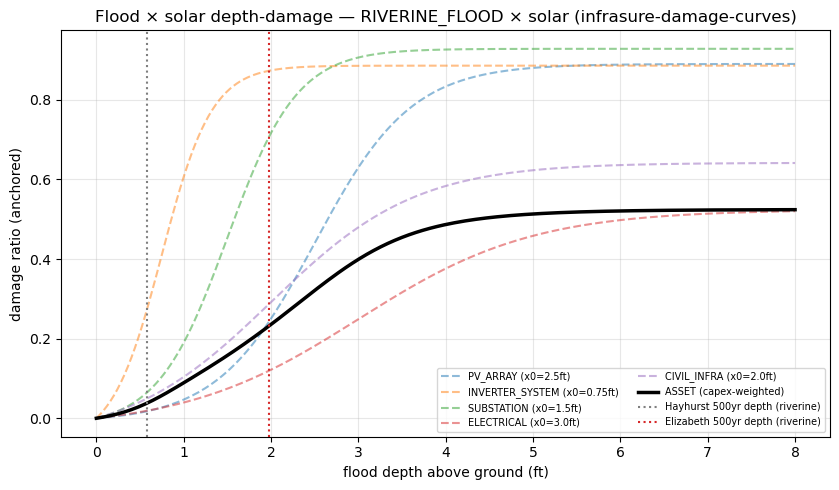

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_m3_damage_curve.png


In [3]:
def asset_dr(depth_ft):
    return float(sum(r.capex_weight * dr_anchored(depth_ft, r.L, r.k, r.x0_ft) for r in curves.itertuples()))


import matplotlib.pyplot as plt

xs = np.linspace(0, 8, 200)
fig, ax = plt.subplots(figsize=(8.5, 5))
for r in curves.itertuples():
    ax.plot(xs, [dr_anchored(x, r.L, r.k, r.x0_ft) for x in xs], "--", alpha=0.5,
            label=f"{r.subsystem} (x0={r.x0_ft}ft)")
ax.plot(xs, [asset_dr(x) for x in xs], "k-", lw=2.5, label="ASSET (capex-weighted)")
for _, s in m2[(m2.rp_years == 500) & (m2.sub_peril == "riverine")].iterrows():
    ax.axvline(s["conditional_depth_m"] / FT_M, color="C3" if "Eliz" in s["name"] else "C7", ls=":",
               label=f"{s['name'].split()[0]} 500yr depth (riverine)")
ax.set_xlabel("flood depth above ground (ft)"); ax.set_ylabel("damage ratio (anchored)")
ax.set_title("Flood × solar depth-damage — RIVERINE_FLOOD × solar (infrasure-damage-curves)")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "flood_m3_damage_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print("wrote:", OUT / "flood_m3_damage_curve.png")

## 3 · Conditional loss per site × return period

`conditional_loss = exposure_fraction × Asset_DR(conditional_depth) × TIV`. TIV from $/MW (Hayhurst's hail TIV
basis, $1.483 M/MW, reused for cross-peril coherence; Elizabeth estimated by capacity).

In [4]:
TIV_PER_MW = 36_778_400 / 24.8     # Hayhurst hail TIV basis
MW = {"Hayhurst Texas Solar": 24.8, "Elizabeth Solar Plant": 142.8}
m2["tiv_usd"] = m2["name"].map(lambda n: round(MW[n] * TIV_PER_MW))
m2["depth_ft"] = m2["conditional_depth_m"] / FT_M
m2["asset_dr"] = m2["depth_ft"].map(asset_dr).round(4)
m2["cond_loss_frac_tiv"] = (m2["exposure_fraction"] * m2["asset_dr"]).round(4)
m2["cond_loss_usd"] = (m2["cond_loss_frac_tiv"] * m2["tiv_usd"]).round(0)
print(m2[["sub_peril", "name", "rp_years", "depth_ft", "exposure_fraction", "asset_dr", "cond_loss_frac_tiv", "cond_loss_usd"]]
      .to_string(index=False))

sub_peril                  name  rp_years  depth_ft  exposure_fraction  asset_dr  cond_loss_frac_tiv  cond_loss_usd
 riverine  Hayhurst Texas Solar       100  0.265748              0.107    0.0122              0.0013        47812.0
 riverine  Hayhurst Texas Solar       500  0.577428              0.161    0.0376              0.0061       224348.0
 riverine Elizabeth Solar Plant        10  0.977690              0.088    0.0861              0.0076      1609470.0
 riverine Elizabeth Solar Plant        25  1.197507              0.117    0.1155              0.0135      2858927.0
 riverine Elizabeth Solar Plant        50  1.358268              0.140    0.1376              0.0193      4087207.0
 riverine Elizabeth Solar Plant       100  1.522310              0.162    0.1610              0.0261      5527260.0
 riverine Elizabeth Solar Plant       500  1.981627              0.191    0.2326              0.0444      9402695.0
  pluvial  Hayhurst Texas Solar        10  0.190289              0.400  

## 4 · Known-answer checks (basics-spot-on)

- **Anchored:** `Asset_DR(0) = 0`. **Inversion:** the inverter (x0 0.75 ft) dominates at shallow depth.
- **Monotone:** damage + conditional loss rise 100-yr → 500-yr. **Contrast:** Elizabeth ≫ Hayhurst.

In [5]:
assert abs(asset_dr(0.0)) < 1e-9, "Asset_DR(0) must be 0 (anchored)"
assert dr_anchored(1.0, 0.95, 3.5, 0.75) > dr_anchored(1.0, 0.9, 1.8, 2.5), "inverter should drown before panels (inversion)"
riv = m2[m2.sub_peril == "riverine"]
eliz = riv[riv.name == "Elizabeth Solar Plant"].set_index("rp_years")
hay = riv[riv.name == "Hayhurst Texas Solar"].set_index("rp_years")
assert eliz.loc[500, "cond_loss_frac_tiv"] >= eliz.loc[100, "cond_loss_frac_tiv"] > 0, "Elizabeth riverine loss should grow 100→500yr"
assert eliz.loc[500, "cond_loss_frac_tiv"] > 3 * hay.loc[500, "cond_loss_frac_tiv"], "Elizabeth riverine should dominate Hayhurst"
# pluvial priced too, monotone, both sites
pluv = m2[(m2.sub_peril == "pluvial") & (m2.name == "Elizabeth Solar Plant")].sort_values("rp_years")
assert pluv["cond_loss_frac_tiv"].is_monotonic_increasing and pluv["cond_loss_frac_tiv"].iloc[-1] > 0, "pluvial loss should grow with RP"
print(f"✓ anchored: Asset_DR(0)=0 | inverter drowns before panels (DR@1ft: inv {dr_anchored(1,0.95,3.5,0.75):.2f} > pv {dr_anchored(1,0.9,1.8,2.5):.2f})")
print(f"✓ riverine Elizabeth: 100yr {eliz.loc[100,'cond_loss_frac_tiv']*100:.2f}% → 500yr {eliz.loc[500,'cond_loss_frac_tiv']*100:.2f}% TIV (grows, dominates Hayhurst)")
print(f"✓ pluvial Elizabeth: 10yr {pluv['cond_loss_frac_tiv'].iloc[0]*100:.2f}% → 500yr {pluv['cond_loss_frac_tiv'].iloc[-1]*100:.2f}% TIV (priced, grows)")
print("✓ M3 known-answer checks pass (riverine + pluvial).")

✓ anchored: Asset_DR(0)=0 | inverter drowns before panels (DR@1ft: inv 0.61 > pv 0.05)
✓ riverine Elizabeth: 100yr 2.61% → 500yr 4.44% TIV (grows, dominates Hayhurst)
✓ pluvial Elizabeth: 10yr 1.44% → 500yr 7.87% TIV (priced, grows)
✓ M3 known-answer checks pass (riverine + pluvial).


## 5 · Vendor the curve + persist the M3 manifest

In [6]:
(OUT / "damage_curves").mkdir(parents=True, exist_ok=True)
vendored = {
    "curve_id": "flood/solar__asset__capex_weighted", "hazard_type": "RIVERINE_FLOOD", "asset_type": "solar",
    "intensity_metric": "flood_depth_ft", "intensity_unit": "ft",
    "logistic_form": "DR(x) = L / (1 + exp(-k*(x - x0)))", "anchoring": "minus DR(0) so DR(0)=0",
    "aggregation": "Asset_DR = Σ wᵢ·DRᵢ_anchored; uncovered→0; loss = exposure × Asset_DR(conditional_depth) × TIV",
    "subsystems": json.loads(curves.to_json(orient="records")),
    "uncovered_subsystems_zero_damage": {**UNCOVERED, "note": "no flood curve → flood-immune"},
    "metadata": {
        "source_repo": "infrasure-damage-curves (Divi-patel/infrasure-damage-curves)",
        "component_curves": "research/FLOOD_x_SOLAR.md via master_curve_index.json (RIVERINE_FLOOD × solar, priority 4)",
        "capex_weights": "NREL solar BoS (vendored from hail_solar_asset_capex_weighted.json) — peril-independent",
        "confidence": "medium; x0 encodes component elevation (the flood inversion); duration unmodeled (Gen-1)",
        "pv_variant": "single-axis horizontal stow (x0 2.5 ft); flood-stow (x0 7 ft) = mitigation lever",
    },
}
(OUT / "damage_curves" / "flood_solar_asset_capex_weighted.json").write_text(json.dumps(vendored, indent=2))

manifest = {
    "peril": "flood", "sub_peril": "riverine", "event_family_id": None, "layer": "M3",
    "curve": "infrasure-damage-curves RIVERINE_FLOOD × solar, capex-weighted, anchored (medium confidence)",
    "conditional_loss_rule": "exposure × Asset_DR(conditional_depth) × TIV",
    "tiv_basis": f"${TIV_PER_MW:,.0f}/MW (Hayhurst hail TIV); Elizabeth estimated",
    "sites": json.loads(m2.to_json(orient="records")),
}
(OUT / "flood_m3_damage_manifest.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "damage_curves" / "flood_solar_asset_capex_weighted.json")
print("wrote:", OUT / "flood_m3_damage_manifest.json")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/damage_curves/flood_solar_asset_capex_weighted.json
wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_m3_damage_manifest.json


## Findings & what's next

- **Canonical depth-damage applied:** the `infrasure-damage-curves` RIVERINE_FLOOD × solar set, capex-weighted —
  same library + recipe as hail/wildfire/wind. The **flood inversion** shows: the inverter (x0 0.75 ft) dominates
  shallow-flood damage; elevated panels and underground cables resist.
- **Conditional loss per site × RP** computed as exposure × Asset_DR × TIV (% of TIV + dollars). Elizabeth grows
  100-yr → 500-yr and dominates the Hayhurst baseline.
- **Honest limits:** medium-confidence curves; duration unmodeled (Gen-1); `value ∝ area` exposure; Elizabeth TIV
  estimated. **Mitigation lever noted:** PV flood-stow (x0 7 ft) for a later resiliency pass.
- **Next — M4 (loss & metrics):** feed the depth-at-RP conditional losses through the shared compound-Poisson MC →
  EAL / VaR / PML / TVaR (% of TIV). **First settle the open event-model bridge** (2-point RP curve → MC).